# Notebook 2 - directory conversion, options, and dependencies

This walkthrough mirrors `examples/03_convert_directory.py` and `examples/04_custom_options.py`. It converts the complete sample warehouse, inspects dependency rewrites, and compares conservative defaults with opt-in migration options.


In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

from sql2sqlx import ConversionOptions, Layout, MergeStrategy, convert_directory, convert_string

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists()
)
EXAMPLES = ROOT / "examples"
assert (EXAMPLES / "sql").is_dir()

## Convert the sample tree

Passing no output directory keeps this notebook side-effect-free: files are returned in memory while preserving the relative paths that would be written under a Dataform `definitions/` directory.


In [2]:
result = convert_directory(str(EXAMPLES / "sql"))
summary = [(file.relpath, file.action_type.value, file.action_name) for file in result.files]
summary, len(summary)

([('maintenance/backfill_script.sqlx', 'operations', 'backfill_script'),
  ('maintenance/customer_attrs_merge.sqlx',
   'operations',
   'customer_attrs_merge'),
  ('maintenance/customers_update.sqlx', 'operations', 'customers_update'),
  ('maintenance/orders_delete.sqlx', 'operations', 'orders_delete'),
  ('marts/customer_orders.sqlx', 'view', 'customer_orders'),
  ('marts/order_facts_insert.sqlx', 'operations', 'order_facts_insert'),
  ('sources/events.sqlx', 'operations', 'events'),
  ('staging/customers.sqlx', 'table', 'customers'),
  ('staging/orders.sqlx', 'table', 'orders')],
 9)

## Confirm dependency-aware rewrites

The converter scans every statement, records produced targets, and rewrites reads of those targets to `${ref(...)}`. It also adds explicit `dependencies` to operations when order matters.


In [3]:
rewritten = [file for file in result.files if "${ref(" in file.content]
for file in rewritten:
    print(f"===== {file.relpath} =====")
    lines = [
        line for line in file.content.splitlines() if "${ref(" in line or "dependencies:" in line
    ]
    print("\n".join(lines))

assert result.report.refs_rewritten >= 1
assert rewritten

===== maintenance/backfill_script.sqlx =====
FROM ${ref("staging", "orders")}
===== maintenance/customer_attrs_merge.sqlx =====
  dependencies: ["customers_update"]
  SELECT customer_id, last_seen FROM ${ref("staging", "customers")}
===== marts/customer_orders.sqlx =====
  dependencies: ["customers_update", "orders_delete"]
FROM ${ref("staging", "customers")} c
LEFT JOIN ${ref("staging", "orders")} o USING (customer_id)
===== marts/order_facts_insert.sqlx =====
  dependencies: ["backfill_script", "orders_delete"]
FROM ${ref("staging", "orders")}
===== staging/customers.sqlx =====
  dependencies: ["customers_update"]
FROM ${ref("raw", "events")}
===== staging/orders.sqlx =====
  dependencies: ["orders_delete"],
FROM ${ref("raw", "events")}


## Visualize the action mix

A directory migration should produce a plausible distribution of Dataform action types. Unexpected spikes in `operations` often identify scripts that require deeper human review.


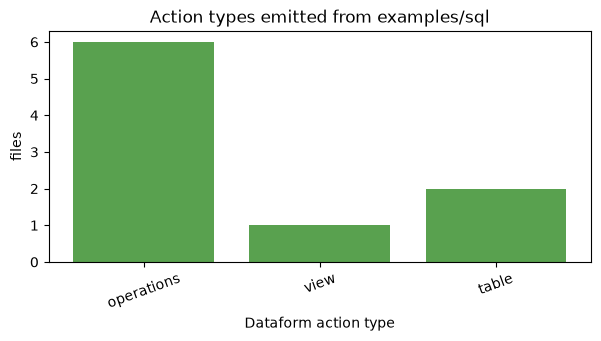

Counter({'operations': 6, 'table': 2, 'view': 1})

In [4]:
counts = Counter(file.action_type.value for file in result.files)
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(counts.keys(), counts.values(), color="#59A14F")
ax.set_title("Action types emitted from examples/sql")
ax.set_ylabel("files")
ax.set_xlabel("Dataform action type")
ax.tick_params(axis="x", rotation=20)
plt.show()
counts

## Compare non-default options

`INCREMENTAL_WHEN_SAFE` converts a MERGE only when the converter can identify deterministic upsert semantics. `Layout.FLAT` is useful when teams want all output files in one folder, and `tags` adds Dataform tags to every generated action.


In [5]:
options = ConversionOptions(
    merge_strategy=MergeStrategy.INCREMENTAL_WHEN_SAFE,
    layout=Layout.FLAT,
    tags=["migrated", "reviewed"],
    annotate=False,
)
custom = convert_directory(str(EXAMPLES / "sql"), options=options)
custom_summary = [(file.relpath, file.action_type.value, file.action_name) for file in custom.files]
custom_summary

[('backfill_script.sqlx', 'operations', 'backfill_script'),
 ('customer_attrs.sqlx', 'incremental', 'customer_attrs'),
 ('customer_orders.sqlx', 'view', 'customer_orders'),
 ('customers.sqlx', 'table', 'customers'),
 ('customers_update.sqlx', 'operations', 'customers_update'),
 ('events.sqlx', 'operations', 'events'),
 ('order_facts_insert.sqlx', 'operations', 'order_facts_insert'),
 ('orders.sqlx', 'table', 'orders'),
 ('orders_delete.sqlx', 'operations', 'orders_delete')]

## Validate option effects

The safe MERGE example becomes an incremental action with `uniqueKey`, and flat layout removes nested directories from output paths.


In [6]:
customer_attrs = next(file for file in custom.files if file.action_name == "customer_attrs")
print(customer_attrs.content)

assert customer_attrs.action_type.value == "incremental"
assert "uniqueKey:" in customer_attrs.content
assert 'tags: ["migrated", "reviewed"]' in customer_attrs.content
assert all("/" not in file.relpath for file in custom.files)
{
    "default_actions": dict(result.report.actions_by_type),
    "custom_actions": dict(custom.report.actions_by_type),
    "custom_warnings": [warning.code for warning in custom.report.warnings],
}

config {
  type: "incremental",
  schema: "staging",
  name: "customer_attrs",
  protected: true,
  uniqueKey: ["customer_id"],
  dependencies: ["customers_update"],
  tags: ["migrated", "reviewed"]
}

-- Upsert latest customer attributes; provably convertible with
-- --merge-strategy incremental-when-safe.
SELECT customer_id, last_seen FROM ${ref("staging", "customers")}



{'default_actions': {'operations': 6, 'view': 1, 'table': 2},
 'custom_actions': {'operations': 5, 'incremental': 1, 'view': 1, 'table': 2},
 'custom_warnings': ['ORDER_ASSUMED',
  'ORDER_ASSUMED',
  'ORDER_ASSUMED',
  'SCRIPT_FILE',
  'SCRIPT_WRITES',
  'MERGE_INCREMENTAL',
  'TARGET_SCHEMA_REQUIRED',
  'CREATE_NO_AS']}

## Synthesize external declarations

When `declare_external=True`, reads of tables not produced by the migration can become Dataform declarations. This lets the migrated project reference upstream warehouse tables explicitly.


In [7]:
external = convert_string(
    "CREATE TABLE marts.fx AS SELECT * FROM ext_finance.currency_rates;",
    ConversionOptions(declare_external=True),
)
for file in external.files:
    print(f"===== {file.relpath} ({file.action_type.value}) =====")
    print(file.content)

assert any(file.action_type.value == "declaration" for file in external.files)
assert (
    '${ref("ext_finance", "currency_rates")}'
    in next(file for file in external.files if file.action_name == "fx").content
)

===== fx.sqlx (table) =====
config {
  type: "table",
  schema: "marts",
  name: "fx"
}

-- source: input.sql:1 (CREATE TABLE converted by sql2sqlx v0.1.0)
SELECT * FROM ${ref("ext_finance", "currency_rates")}

===== sources/currency_rates.sqlx (declaration) =====
config {
  type: "declaration",
  schema: "ext_finance",
  name: "currency_rates"
}

